In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Loading the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

#  Inspect shape and missing values
print("- Dataset Shape -")
print(df.shape)
print("\n- Missing Values Per Column -")
print(df.isnull().sum())

#  Convert Dates to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#  Feature Engineering: Calculate days taken to ship
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print("\n- Quick Shipping Days Summary -")
print(df['days_to_ship'].describe())

- Dataset Shape -
(9994, 21)

- Missing Values Per Column -
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

- Quick Shipping Days Summary -
count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: days_to_ship, dtype: float64


In [8]:
#  Multi-Level Aggregation: Sales and Profit by Region, Category, and Sub-Category
multi_agg = df.groupby(['Region', 'Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Sales', 'count')
).reset_index()

print("- Sample Multi-level Aggregation -")
print(multi_agg.head(10))
print("-" * 50)

#  Identify Top 5 and Bottom 5 Sub-Categories by Profit
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print("- Top 5 Most Profitable Sub-Categories -")
print(subcat_profit.head(5))
print("\n- Bottom 5 Least Profitable Sub-Categories (Underperformers) -")
print(subcat_profit.tail(5))

- Sample Multi-level Aggregation -
    Region         Category Sub-Category  Total_Sales  Total_Profit  \
0  Central        Furniture    Bookcases   24157.1768    -1997.9043   
1  Central        Furniture       Chairs   85230.6460     6592.7221   
2  Central        Furniture  Furnishings   15254.3700    -3906.2168   
3  Central        Furniture       Tables   39154.9710    -3559.6504   
4  Central  Office Supplies   Appliances   23582.0330    -2638.6175   
5  Central  Office Supplies          Art    5765.3400     1195.1591   
6  Central  Office Supplies      Binders   56923.2820    -1043.6369   
7  Central  Office Supplies    Envelopes    4636.8720     1777.5283   
8  Central  Office Supplies    Fasteners     778.0300      236.6186   
9  Central  Office Supplies       Labels    2451.4720     1073.0794   

   Order_Count  
0           50  
1          154  
2          205  
3           72  
4          123  
5          176  
6          366  
7           59  
8           55  
9           7

C:\Users\nusre\AppData\Local\Temp\ipykernel_6384\3260934331.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_df, x='Profit', y='Sub-Category', palette=colors, edgecolor='black')


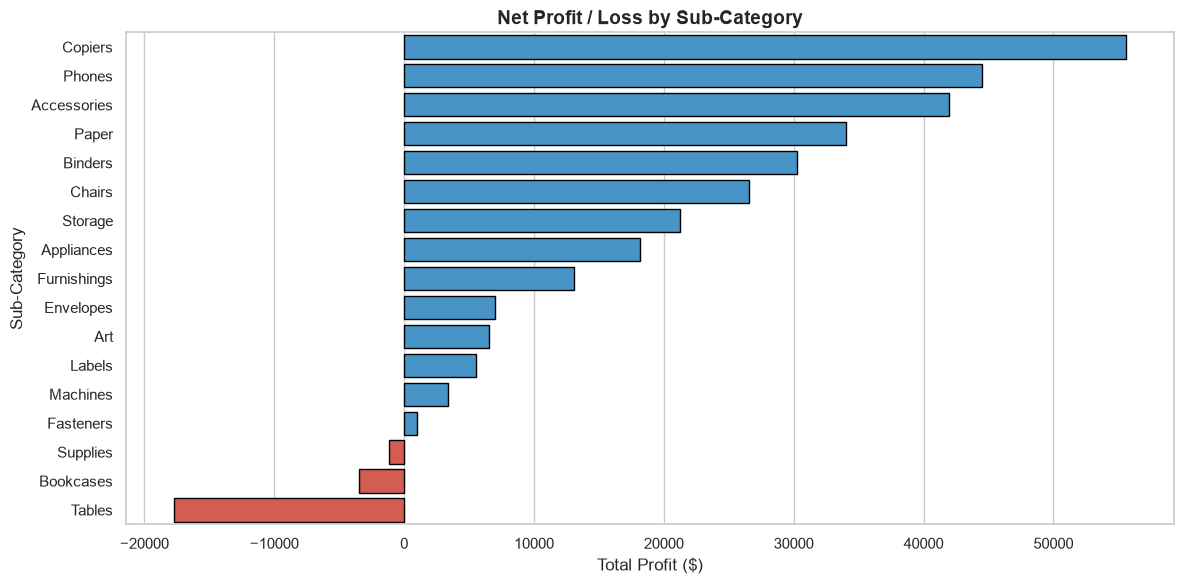

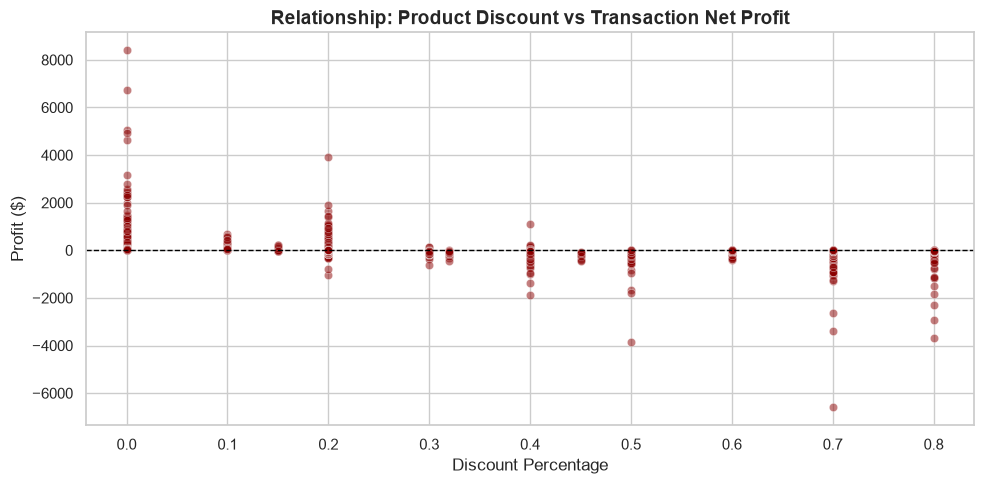

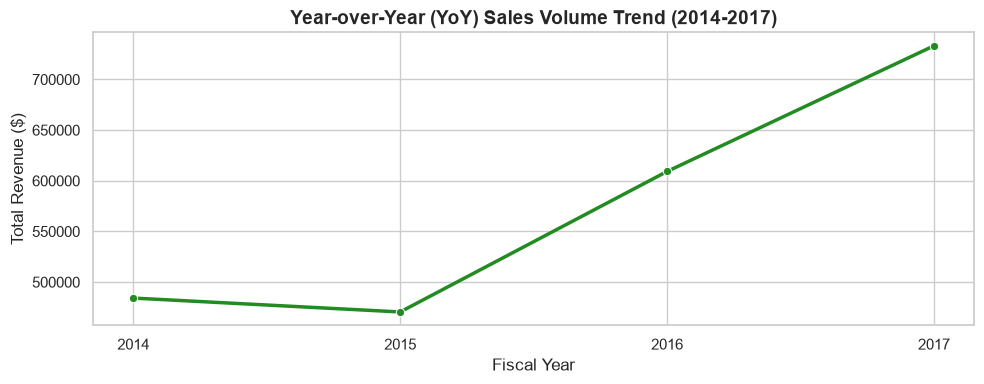

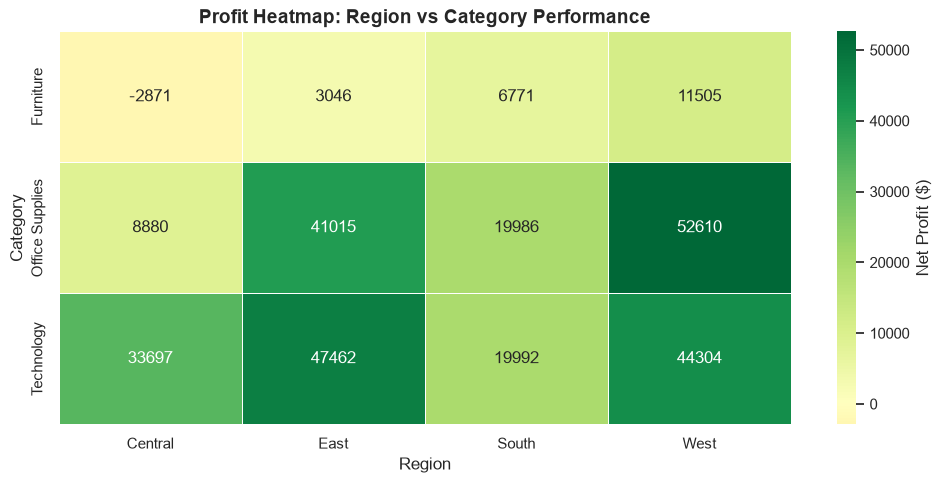

In [9]:
# Set up styling
sns.set_theme(style="whitegrid")

# CHART 1: Profit by Sub-Category (Color-coded to highlight negatives) 
plt.figure(figsize=(12, 6))
subcat_df = subcat_profit.reset_index()
# Create a custom color palette: Red for negative profit, Blue for positive
colors = ['#e74c3c' if x < 0 else '#3498db' for x in subcat_df['Profit']]

sns.barplot(data=subcat_df, x='Profit', y='Sub-Category', palette=colors, edgecolor='black')
plt.title('Net Profit / Loss by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

#  CHART 2: Scatter Plot of Discount vs Profit 
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='darkred')
plt.title('Relationship: Product Discount vs Transaction Net Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Percentage')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Baseline line at $0
plt.tight_layout()
plt.show()

#  CHART 3: Yearly Sales Trend Line 
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly_sales, x='Year', y='Sales', marker='o', color='forestgreen', linewidth=2.5)
plt.title('Year-over-Year (YoY) Sales Volume Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Revenue ($)')
plt.xticks(yearly_sales['Year'])
plt.tight_layout()
plt.show()

#  Profit Distribution Heatmap (Region vs Category)
plt.figure(figsize=(10, 5))
profit_pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')
sns.heatmap(profit_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0, linewidths=.5, cbar_kws={'label': 'Net Profit ($)'})
plt.title('Profit Heatmap: Region vs Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()